# 선형 회귀 / 특성 공학과 규제 / 로지스틱 회귀

## 1. 선형 회귀 (Linear Regression)

### 1-1. k-최근접 이웃의 한계
- k-NN 회귀는 예측하려는 샘플의 값이 훈련 세트 범위를 벗어나면(예: 아주 큰 값)     
  가장 가까운 이웃들의 평균으로만 예측하므로 훈련 범위 밖에서는 예측이 무뎌지는 한계가 있다.
- 이를 보완하기 위해 **선형 회귀**를 사용한다.

### 1-2. 선형 회귀란
- 대표적인 회귀 알고리즘. 비교적 간단하지만 성능이 뛰어남.
- 특성이 하나인 경우, 하나의 직선(1차 방정식)을 학습한다.
  - $y = a \cdot x + b$
- 훈련 세트에 잘 맞는 직선을 찾는다 = 최적의 기울기(`coef_`)와 절편(`intercept_`)을 구한다.
- **한계**: 직선으로 예측하다 보니 특성 값이 작아지면 타깃 값이 0 이하로 예측될 수 있음
  (생물의 무게처럼 0이 될 수 없는 값에는 부적절).

### 1-3. 다항 회귀 (Polynomial Regression)
- 직선이 아니라 **곡선**을 학습하도록 만드는 방법.
- 기존 특성을 제곱한 항을 추가해서 선형 회귀로 학습하면 다항식(곡선)을 학습할 수 있음.
  - $y = a \cdot x^2 + b \cdot x + c$ (2차 방정식)
- 여전히 **선형 회귀**다 — 계수 $a, b$에 대해 선형이기 때문. 특성을 비선형으로 확장했을 뿐.

### 1-4. 다중 회귀 (Multiple Regression)
- 여러 개의 특성을 사용하는 선형 회귀.
  - 특성 1개 → 직선을 학습
  - 특성 2개 → 평면을 학습 (타깃까지 포함해 3차원 공간)
  - 특성 3개 이상 → 시각화는 불가능하지만 여전히 방정식으로는 표현 가능
- 특성이 단순 직선/평면이라고 해서 성능이 낮은 것은 아님. 
  **고차원에서는 선형 회귀도 매우 복잡한 모델을 표현할 수 있다.**
- 기존 특성끼리 제곱하거나 곱해서 새로운 특성을 만드는 작업 = **특성 공학(Feature Engineering)**

---

## 2. 특성 공학과 규제

### 2-1. PolynomialFeatures
- `sklearn.preprocessing.PolynomialFeatures`로 특성 조합을 자동 생성.
- `fit()` → 어떤 특성 조합을 만들지 학습, `transform()` → 실제 변환 수행.
- `include_bias=False`로 절편(1) 항 제거 (사이킷런 모델이 자체적으로 절편 추가하므로 불필요).
- `get_feature_names_out()`으로 만들어진 특성 조합 이름 확인 가능.
- `degree` 매개변수로 몇 제곱까지 특성을 만들지 조절 (degree가 커질수록 특성 수 폭증 → 과대적합 위험).

### 2-2. 규제 (Regularization)
- 모델이 훈련 세트에 **너무 과도하게** 학습되지 않도록 훼방하는 것.
- 선형 회귀에서는 특성에 곱해지는 **계수의 크기**를 작게 만드는 것.
- 계수 크기가 특성마다 스케일이 다르면 공정한 규제가 안 되므로, 
  규제 전에 반드시 **정규화(StandardScaler)** 를 먼저 수행.

### 2-3. 릿지(Ridge) vs 라쏘(Lasso)
| 구분 | 기준 |
|---|---|
| 릿지 | 계수를 **제곱**한 값 기준으로 규제 (L2) |
| 라쏘 | 계수의 **절댓값** 기준으로 규제 (L1) |

- 일반적으로 **릿지**를 조금 더 선호.
- 두 알고리즘 모두 계수를 줄이지만, **라쏘는 계수를 완전히 0으로 만들 수도 있음** 
  (= 특성 선택 효과).

### 2-4. alpha 하이퍼파라미터
- 규제 강도를 조절하는 매개변수.
- `alpha` ↑ → 규제 강함 → 계수 더 많이 축소 → **과소적합** 유도
- `alpha` ↓ → 규제 약함 → 선형 회귀와 유사해짐 → **과대적합** 가능성 ↑
- 적절한 alpha는 훈련/테스트 점수를 그래프로 그려, 
  두 점수가 가장 가까워지는 지점을 찾아서 결정.

---

## 3. 로지스틱 회귀 (Logistic Regression)

### 3-1. 개념
- 이름은 회귀지만 **분류 모델**.
- 선형 회귀와 동일하게 선형 방정식을 학습:
  - $z = a_1 x_1 + a_2 x_2 + \cdots + a_n x_n + b$
- $z$는 어떤 값도 될 수 있지만, 확률이 되려면 0~1 사이여야 함 
  → **시그모이드 함수(이진 분류)** 또는 **소프트맥스 함수(다중 분류)** 사용.

### 3-2. 이진 분류 — 시그모이드 함수
- $z$를 0~1 사이 값으로 압축.
- 출력값 = 양성 클래스에 대한 확률, 음성 클래스 확률 = 1 - 양성 확률.

### 3-3. 다중 분류 — 소프트맥스 함수
- 클래스 개수만큼 선형 방정식을 훈련 (예: 클래스가 3개면 $z_1, z_2, z_3$).
- 소프트맥스: 각 $z$ 값에 지수함수를 적용해 모두 더한 값(`e_sum`)으로 
  각각을 나눠서 확률로 변환 → 전체 합이 항상 1이 되도록 정규화.
  - $S_i = \dfrac{e^{z_i}}{\sum_{j} e^{z_j}}$

### 3-4. 하이퍼파라미터
- `max_iter`: 반복 학습 횟수 (기본값 100)
- `C`: 규제 강도를 제어 (기본적으로 L2 규제 사용). **작을수록 규제가 커짐** 
  (Ridge/Lasso의 alpha와 반대 방향이니 주의!)

### 3-5. 정리
- k-NN도 확률을 출력할 수 있지만, 이웃 클래스 비율로만 정해지는 계단식 확률이라 한계가 있음.
- 로지스틱 회귀는 선형 방정식의 출력을 확률로 매끄럽게 변환해주는 대표적인 분류 알고리즘.

# 실습

In [1]:
# 선형 회귀 (특성 1개 - 예제)

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

diabetes = load_diabetes()
print(diabetes.feature_names)

# bmi 특성 하나만 사용 (인덱스 2)
X = diabetes.data[:, [2]]
y = diabetes.target

train_input, test_input, train_target, test_target = train_test_split(
    X, y, random_state=42
)

lr = LinearRegression()
lr.fit(train_input, train_target)

print("계수, 절편:", lr.coef_, lr.intercept_)
print("훈련 점수:", lr.score(train_input, train_target))
print("테스트 점수:", lr.score(test_input, test_target))

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
계수, 절편: [975.27698313] 152.07653296894014
훈련 점수: 0.34967185121455036
테스트 점수: 0.3172099449537781


-  bmi(체질량지수) 하나만으로는 당뇨병 진행 정도를 설명하는 데 한계가 있다.

In [2]:
# 다항 회귀
# 다항 특성 직접 추가 (bmi^2, bmi)
import numpy as np

train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

lr = LinearRegression()
lr.fit(train_poly, train_target)

print("계수, 절편:", lr.coef_, lr.intercept_)
print("훈련 점수:", lr.score(train_poly, train_target))
print("테스트 점수:", lr.score(test_poly, test_target))

계수, 절편: [894.87986618 946.69248208] 150.14960310703498
훈련 점수: 0.3507638912961788
테스트 점수: 0.31213932231550556


- bmi 하나로는 제곱항을 추가해도 큰 개선은 없었다.

In [3]:
#  다중 회귀 + PolynomialFeatures
# 특성 3개 사용: bmi, bp(혈압), s5
from sklearn.preprocessing import PolynomialFeatures

X = diabetes.data[:, [2, 3, 8]]
y = diabetes.target

train_input, test_input, train_target, test_target = train_test_split(X, y, random_state=42)

In [4]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print("변환된 특성 shape:", train_poly.shape)          
print("특성 조합:", poly.get_feature_names_out())

변환된 특성 shape: (331, 9)
특성 조합: ['x0' 'x1' 'x2' 'x0^2' 'x0 x1' 'x0 x2' 'x1^2' 'x1 x2' 'x2^2']


In [5]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

print("훈련 점수:", lr.score(train_poly, train_target))  
print("테스트 점수:", lr.score(test_poly, test_target))  

훈련 점수: 0.4836289481127273
테스트 점수: 0.5136309322429718


In [6]:
# 특성을 훨씬 많이 늘려서 과대적합 확인 (5제곱)
poly5 = PolynomialFeatures(degree=5, include_bias=False)
poly5.fit(train_input)
train_poly5 = poly5.transform(train_input)
test_poly5 = poly5.transform(test_input)

print("degree=5 특성 shape:", train_poly5.shape)

degree=5 특성 shape: (331, 55)


In [7]:
lr5 = LinearRegression()
lr5.fit(train_poly5, train_target)

print("degree=5 훈련 점수:", lr5.score(train_poly5, train_target))  
print("degree=5 테스트 점수:", lr5.score(test_poly5, test_target))

degree=5 훈련 점수: 0.5381966095186289
degree=5 테스트 점수: 0.21978611146327243


- 테스트 점수는 오르는데 과대적합이 확인되는 지점이다.

In [8]:
# 규제 (릿지 & 라쏘) + alpha 튜닝
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso

# 규제 전 표준화
ss = StandardScaler()
ss.fit(train_poly5)
train_scaled = ss.transform(train_poly5)
test_scaled = ss.transform(test_poly5)

In [9]:
# 4. 릿지 - alpha 튜닝
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    print(f"alpha={alpha:>6} 훈련={ridge.score(train_scaled, train_target):.4f} "
          f"테스트={ridge.score(test_scaled, test_target):.4f}")

alpha= 0.001 훈련=0.5517 테스트=0.1666
alpha=  0.01 훈련=0.5517 테스트=0.1829
alpha=   0.1 훈련=0.5511 테스트=0.2825
alpha=     1 훈련=0.5441 테스트=0.4147
alpha=    10 훈련=0.5246 테스트=0.4874
alpha=   100 훈련=0.4886 테스트=0.4766


In [10]:
# 5. 라쏘 - alpha 튜닝

for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    n_used = np.sum(lasso.coef_ != 0)
    print(f"alpha={alpha:>6} 훈련={lasso.score(train_scaled, train_target):.4f} "
          f"테스트={lasso.score(test_scaled, test_target):.4f} "
          f"사용특성수={n_used}/{train_poly5.shape[1]}")

alpha= 0.001 훈련=0.5517 테스트=0.1748 사용특성수=55/55
alpha=  0.01 훈련=0.5513 테스트=0.2560 사용특성수=54/55
alpha=   0.1 훈련=0.5384 테스트=0.4531 사용특성수=47/55
alpha=     1 훈련=0.5001 테스트=0.5203 사용특성수=16/55
alpha=    10 훈련=0.4429 테스트=0.4767 사용특성수=4/55
alpha=   100 훈련=0.0000 테스트=-0.0140 사용특성수=0/55


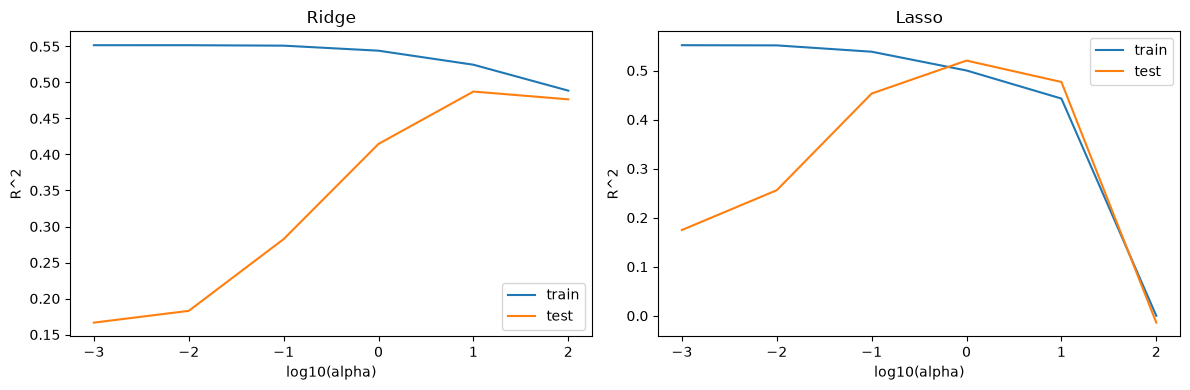

In [11]:
# alpha별 R² 그래프

import matplotlib.pyplot as plt

train_score_r, test_score_r = [], []
train_score_l, test_score_l = [], []

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score_r.append(ridge.score(train_scaled, train_target))
    test_score_r.append(ridge.score(test_scaled, test_target))

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score_l.append(lasso.score(train_scaled, train_target))
    test_score_l.append(lasso.score(test_scaled, test_target))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.log10(alpha_list), train_score_r, label='train')
axes[0].plot(np.log10(alpha_list), test_score_r, label='test')
axes[0].set_xlabel('log10(alpha)')
axes[0].set_ylabel('R^2')
axes[0].set_title('Ridge')
axes[0].legend()

axes[1].plot(np.log10(alpha_list), train_score_l, label='train')
axes[1].plot(np.log10(alpha_list), test_score_l, label='test')
axes[1].set_xlabel('log10(alpha)')
axes[1].set_ylabel('R^2')
axes[1].set_title('Lasso')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# 로지스틱 회귀 다중분류

import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.special import softmax

# 데이터 준비
wine = load_wine()
print("클래스:", wine.target_names)  # ['class_0' 'class_1' 'class_2']

X = wine.data
y = wine.target

train_input, test_input, train_target, test_target = train_test_split(
    X, y, random_state=42
)


클래스: ['class_0' 'class_1' 'class_2']


In [13]:
# 표준화

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [14]:
# 로지스틱 회귀 학습

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

print("훈련 점수:", lr.score(train_scaled, train_target))   
print("테스트 점수:", lr.score(test_scaled, test_target))

훈련 점수: 1.0
테스트 점수: 0.9777777777777777


In [15]:
# 테스트 세트 앞 5개 샘플의 z값(decision_function)

decision = lr.decision_function(test_scaled[:5])
print("\nz값 (클래스별 3개씩):\n", np.round(decision, decimals=2))


z값 (클래스별 3개씩):
 [[ 7.6  -4.46 -3.14]
 [ 7.58 -7.   -0.57]
 [-2.26 -2.6   4.85]
 [ 6.82 -2.52 -4.3 ]
 [-2.55  8.22 -5.67]]


In [16]:
# 소프트맥스로 직접 확률 변환 (axis=1: 샘플별 정규화)
proba = softmax(decision, axis=1)
print("\n직접 계산한 소프트맥스 확률:\n", np.round(proba, decimals=3))

# 사이킷런의 predict_proba와 비교
print("\npredict_proba 결과:\n", np.round(lr.predict_proba(test_scaled[:5]), decimals=3))


직접 계산한 소프트맥스 확률:
 [[1.    0.    0.   ]
 [1.    0.    0.   ]
 [0.001 0.001 0.999]
 [1.    0.    0.   ]
 [0.    1.    0.   ]]

predict_proba 결과:
 [[1.    0.    0.   ]
 [1.    0.    0.   ]
 [0.001 0.001 0.999]
 [1.    0.    0.   ]
 [0.    1.    0.   ]]
